# VNI Forecasting

This notebook is a VNI-focused version of `clean_data.ipynb`. It loads `VNI.csv`, cleans numeric columns, and builds ARIMA/LSTM forecasts on the Close series.

In [22]:
# Install only if needed in your current kernel
# %pip install pandas numpy matplotlib statsmodels scikit-learn prophet

import warnings
warnings.filterwarnings('ignore')
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [23]:
df = pd.read_csv(r"data/VNINDEX_Full_History.csv", sep=",")

# Drop trailing empty column if present from CSV export
df['time'] = pd.to_datetime(df['time'])

print('Shape:', df.shape)
display(df.head())
display(df.tail())

Shape: (3351, 6)


,time,open,high,low,close,volume
0,2013-01-02 07:00:00,415.50,419.05,414.41,418.35,60311180
1,2013-01-03 07:00:00,420.68,420.68,413.68,419.27,96108870
2,2013-01-04 07:00:00,418.75,426.48,417.50,426.06,62614690
3,2013-01-07 07:00:00,428.53,434.64,426.86,434.19,75004280
4,2013-01-08 07:00:00,437.25,447.16,437.15,447.16,81496290


,time,open,high,low,close,volume
3346,2026-06-08 07:00:00,1822.10,1838.90,1789.31,1790.53,613416648
3347,2026-06-09 07:00:00,1799.21,1800.80,1780.71,1793.05,423962378
3348,2026-06-10 07:00:00,1793.45,1805.03,1789.48,1803.71,459074178
3349,2026-06-11 07:00:00,1793.15,1803.71,1788.64,1798.61,376827746
3350,2026-06-12 07:00:00,1803.29,1813.57,1783.16,1791.65,640199320



=== Descriptive Statistics: VNI Close Price ===

                     Value
Mean          9.751640e+02
Median        9.707500e+02
Maximum       1.927940e+03
Minimum       4.183500e+02
Std. dev.     3.508869e+02
Skewness      4.424700e-01
Kurtosis     -4.946879e-01
Jarque-Bera   1.435114e+02
Probability   6.868941e-32
Sum           3.267775e+06
Sum Sq. dev.  4.124574e+08
Observations  3.351000e+03


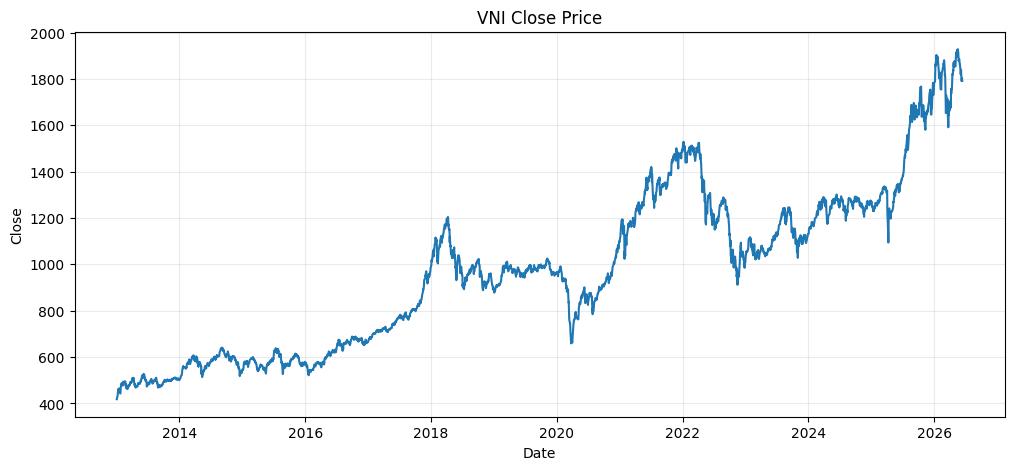

In [24]:
from scipy import stats

# Compute comprehensive descriptive statistics for Close price
close_price = df['close'].astype(float).dropna()

# Jarque-Bera test
jb_stat, jb_pval = stats.jarque_bera(close_price)

stats_dict = {
    'Mean': [close_price.mean()],
    'Median': [close_price.median()],
    'Maximum': [close_price.max()],
    'Minimum': [close_price.min()],
    'Std. dev.': [close_price.std()],
    'Skewness': [stats.skew(close_price)],
    'Kurtosis': [stats.kurtosis(close_price)],
    'Jarque-Bera': [jb_stat],
    'Probability': [jb_pval],
    'Sum': [close_price.sum()],
    'Sum Sq. dev.': [((close_price - close_price.mean()) ** 2).sum()],
    'Observations': [len(close_price)]
}

# Create DataFrame
stats_table = pd.DataFrame(stats_dict).T
stats_table.columns = ['Value']
print('\n=== Descriptive Statistics: VNI Close Price ===\n')
print(stats_table)

plt.figure(figsize=(12, 5))
plt.plot(df['time'], df['close'], color='tab:blue', linewidth=1.5)
plt.title('VNI Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_close_price.png', dpi=300, bbox_inches='tight')
plt.show()



=== Descriptive Statistics: First-Differenced VNI Close Price ===

                      Value
Mean               0.409940
Median             1.045000
Maximum           79.010000
Minimum         -115.050000
Std. dev.         12.392189
Skewness          -1.175126
Kurtosis           9.417724
Jarque-Bera    13151.151863
Probability        0.000000
Sum             1373.300000
Sum Sq. dev.  514293.739188
Observations    3350.000000


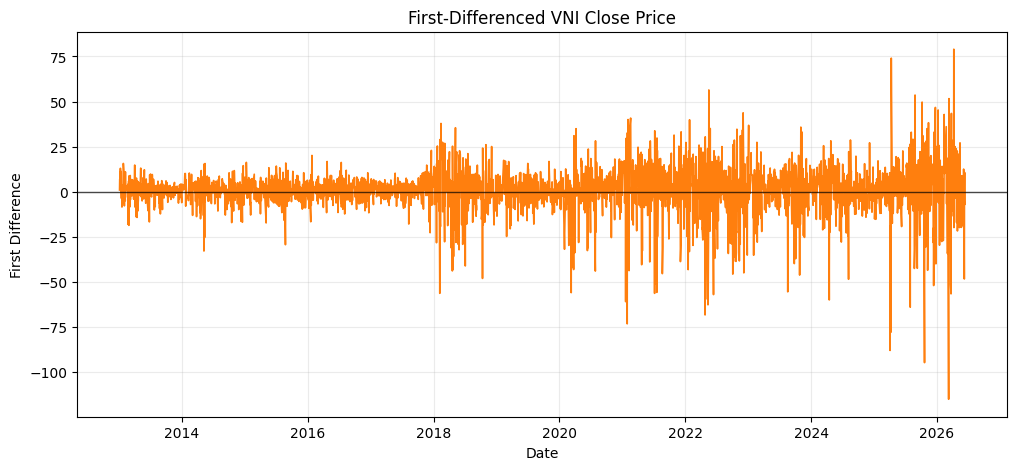

In [25]:
from scipy import stats

# First-difference the Close price series
close_price_diff = df['close'].astype(float).dropna().diff().dropna()

# Jarque-Bera test on the differenced series
jb_stat_diff, jb_pval_diff = stats.jarque_bera(close_price_diff)

diff_stats_dict = {
    'Mean': [close_price_diff.mean()],
    'Median': [close_price_diff.median()],
    'Maximum': [close_price_diff.max()],
    'Minimum': [close_price_diff.min()],
    'Std. dev.': [close_price_diff.std()],
    'Skewness': [stats.skew(close_price_diff)],
    'Kurtosis': [stats.kurtosis(close_price_diff)],
    'Jarque-Bera': [jb_stat_diff],
    'Probability': [jb_pval_diff],
    'Sum': [close_price_diff.sum()],
    'Sum Sq. dev.': [((close_price_diff - close_price_diff.mean()) ** 2).sum()],
    'Observations': [len(close_price_diff)]
}

# Print descriptive statistics table
diff_stats_table = pd.DataFrame(diff_stats_dict).T
diff_stats_table.columns = ['Value']
print('\n=== Descriptive Statistics: First-Differenced VNI Close Price ===\n')
print(diff_stats_table)

# Plot the differenced series
plt.figure(figsize=(12, 5))
plt.plot(df['time'].iloc[1:], close_price_diff, color='tab:orange', linewidth=1.2)
plt.axhline(0, color='black', linewidth=1, alpha=0.7)
plt.title('First-Differenced VNI Close Price')
plt.xlabel('Date')
plt.ylabel('First Difference')
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_first_differenced_price.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test on the first-differenced Close price series
adf_result = adfuller(close_price_diff, autolag='AIC')

adf_stat = adf_result[0]
adf_pvalue = adf_result[1]
adf_crit_values = adf_result[4]

print('\n=== ADF Test: First-Differenced VNI Close Price ===\n')
print(f'ADF Test Statistic: {adf_stat:.6f}')
print(f'p-value: {adf_pvalue:.6f}')
print('Critical Values:')
for key, value in adf_crit_values.items():
    print(f'  {key}: {value:.6f}')


=== ADF Test: First-Differenced VNI Close Price ===

ADF Test Statistic: -16.631224
p-value: 0.000000
Critical Values:
  1%: -3.432311
  5%: -2.862406
  10%: -2.567231


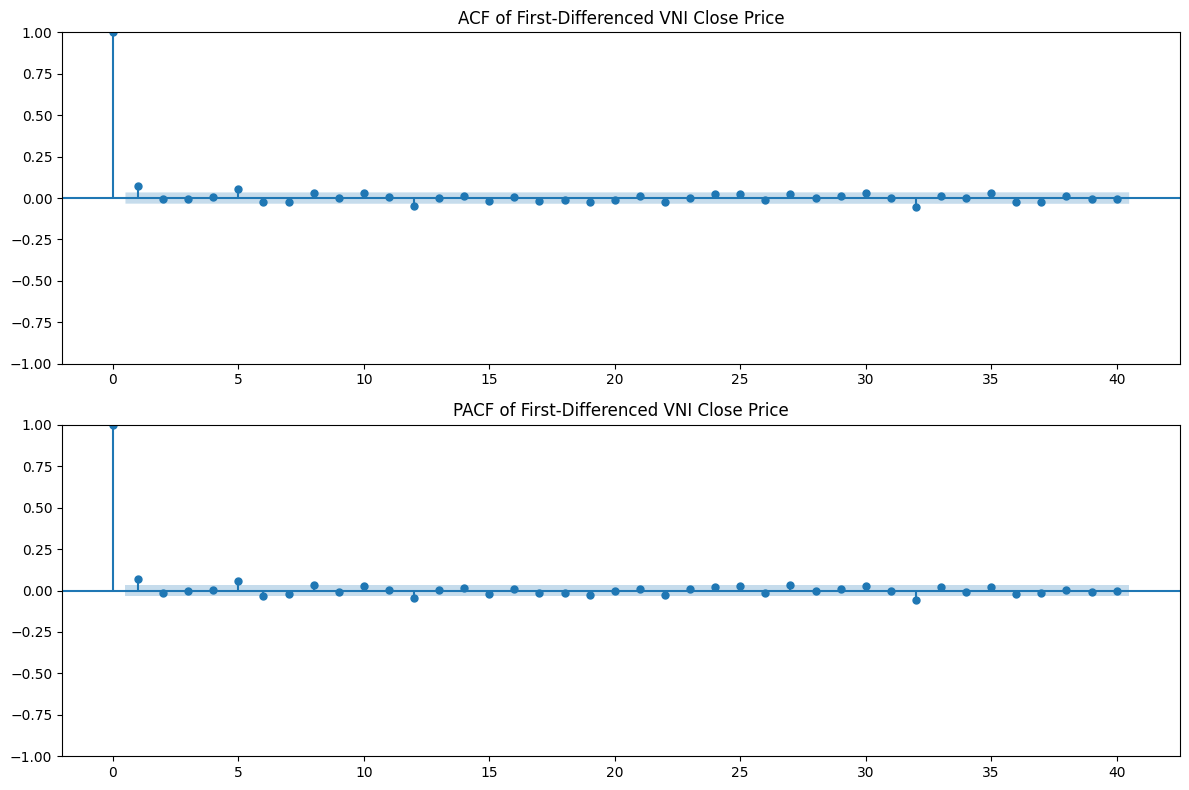

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Correlogram for the first-differenced Close price series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(close_price_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF of First-Differenced VNI Close Price')

plot_pacf(close_price_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF of First-Differenced VNI Close Price')

plt.tight_layout()
plt.savefig('plot/vni_correlogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
from itertools import product

# First, prepare the train/test split
series = df.set_index('time')['close']
split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

# Quick ARIMA order search - test only promising combinations
# Based on typical financial time series patterns, test a focused set
promising_orders = [
    (1, 1, 1), (1, 1, 2), (2, 1, 1), (2, 1, 2),
    (3, 1, 1), (3, 1, 2), (4, 1, 1), (4, 1, 2),
    (1, 0, 1), (2, 0, 1), (3, 0, 1),
]

order_results = []
best_aic = np.inf
best_order = None
best_fit = None

print(f'Testing {len(promising_orders)} focused ARIMA parameter combinations...\n')

for idx, order in enumerate(promising_orders):
    try:
        print(f'  Testing order {order}...')
        candidate_fit = ARIMA(train, order=order).fit()
        order_results.append({
            'order': order,
            'aic': candidate_fit.aic,
            'bic': candidate_fit.bic,            
        })
        print(f'    ✓ AIC: {candidate_fit.aic:.2f}')
        if candidate_fit.aic < best_aic:
            best_aic = candidate_fit.aic
            best_order = order
            best_fit = candidate_fit
    except Exception as e:
        print(f'    ✗ Failed: {str(e)[:50]}...')
        continue

print()

if order_results:
    order_results_df = pd.DataFrame(order_results).sort_values('aic').reset_index(drop=True)
    print('\n=== ARIMA Order Search Results (sorted by AIC) ===\n')
    display(order_results_df)
    print(f"\nBest ARIMA order by AIC: {best_order} (AIC = {best_aic:.3f})")
else:
    print("Warning: No successful ARIMA fits found. Using default order (4, 1, 2).")
    best_order = (4, 1, 2)
    best_aic = np.inf

Testing 11 focused ARIMA parameter combinations...

  Testing order (1, 1, 1)...
    ✓ AIC: 20387.92
  Testing order (1, 1, 2)...
    ✓ AIC: 20389.88
  Testing order (2, 1, 1)...
    ✓ AIC: 20389.88
  Testing order (2, 1, 2)...
    ✓ AIC: 20391.89
  Testing order (3, 1, 1)...
    ✓ AIC: 20391.87
  Testing order (3, 1, 2)...
    ✓ AIC: 20393.80
  Testing order (4, 1, 1)...
    ✓ AIC: 20392.88
  Testing order (4, 1, 2)...
    ✓ AIC: 20389.07
  Testing order (1, 0, 1)...
    ✓ AIC: 20408.04
  Testing order (2, 0, 1)...
    ✓ AIC: 20406.00
  Testing order (3, 0, 1)...
    ✓ AIC: 20409.83


=== ARIMA Order Search Results (sorted by AIC) ===



,order,aic,bic
0,"(1, 1, 1)",20387.919863,20405.599460
1,"(4, 1, 2)",20389.072025,20430.324417
2,"(2, 1, 1)",20389.875065,20413.447860
3,"(1, 1, 2)",20389.875332,20413.448128
4,"(3, 1, 1)",20391.870444,20421.336439
5,"(2, 1, 2)",20391.886658,20421.352652
6,"(4, 1, 1)",20392.877024,20428.236217
7,"(3, 1, 2)",20393.800707,20429.159900
8,"(2, 0, 1)",20405.998462,20435.466322
9,"(1, 0, 1)",20408.041097,20431.615385



Best ARIMA order by AIC: (1, 1, 1) (AIC = 20387.920)


In [29]:
series = df.set_index('time')['close']

split_idx = int(len(series) * 0.8)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f'Train size: {len(train)} | Test size: {len(test)}')

# Use the AIC-selected order if the search cell was run; otherwise fall back to the previous baseline order.
try:
    order = best_order
except NameError:
    order = (4, 1, 2)

model = ARIMA(train, order=order)
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
mape = mean_absolute_percentage_error(test, pred) * 100
correlation = np.corrcoef(test, pred)[0, 1]

print('ARIMA order:', order)
print(f'RMSE: {rmse:.3f}')
print(f'MAE : {mae:.3f}')
print(f'MAPE: {mape:.3f}%')
print(f'Correlation: {correlation:.4f}')

Train size: 2680 | Test size: 671
ARIMA order: (1, 1, 1)
RMSE: 352.214
MAE : 261.929
MAPE: 16.491%
Correlation: -0.1035


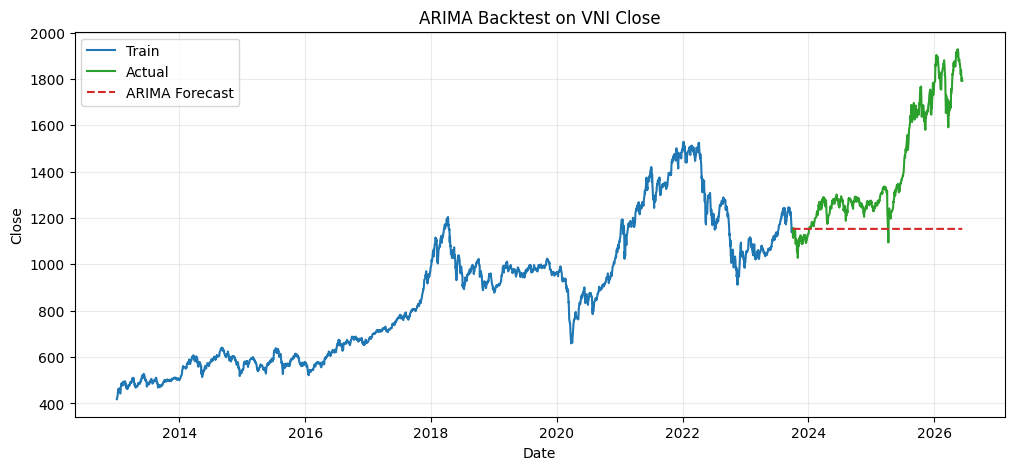

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Train', color='tab:blue')
plt.plot(test.index, test, label='Actual', color='tab:green')
plt.plot(test.index, pred, label='ARIMA Forecast', color='tab:red', linestyle='--')
plt.title('ARIMA Backtest on VNI Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_arima_backtest.png', dpi=300, bbox_inches='tight')
plt.show()

,Date,ARIMA_Forecast
0,2026-06-15,1788.429879
1,2026-06-16,1788.448618
2,2026-06-17,1789.100918
3,2026-06-18,1788.853001
4,2026-06-19,1788.425769


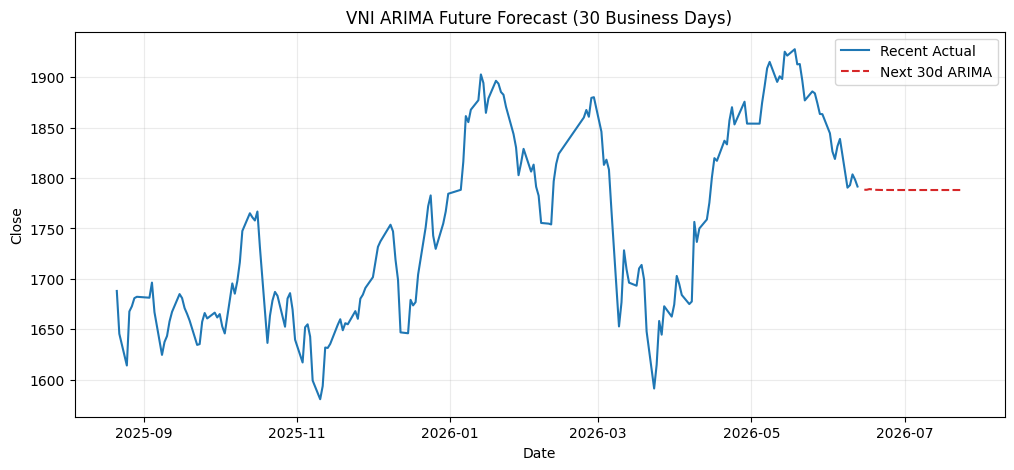

In [31]:
# Fit on full history and forecast next 30 business days
future_steps = 30
final_model = ARIMA(series, order=(5, 1, 0)).fit()
future_arima = final_model.forecast(steps=future_steps)
future_dates = pd.bdate_range(series.index[-1] + pd.offsets.BDay(1), periods=future_steps)

arima_fc_df = pd.DataFrame({'Date': future_dates, 'ARIMA_Forecast': future_arima.values})
display(arima_fc_df.head())

plt.figure(figsize=(12, 5))
plt.plot(series.index[-200:], series.values[-200:], label='Recent Actual', color='tab:blue')
plt.plot(arima_fc_df['Date'], arima_fc_df['ARIMA_Forecast'], label='Next 30d ARIMA', color='tab:red', linestyle='--')
plt.title('VNI ARIMA Future Forecast (30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True, alpha=0.25)
plt.savefig('plot/vni_arima_future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# ARCH-LM Test on ARIMA Residuals
from statsmodels.stats.diagnostic import het_arch
import numpy as np
import pandas as pd

# Get residuals from ARIMA model
arima_residuals = final_model.resid

# Display basic statistics about residuals
print("ARCH-LM Test Results (ARIMA Residuals)")
print("=" * 70)
print(f"\nNumber of observations: {len(arima_residuals)}")
print(f"Residuals Mean: {arima_residuals.mean():.6f}")
print(f"Residuals Std Dev: {arima_residuals.std():.6f}")
print(f"Residuals Min: {arima_residuals.min():.6f}")
print(f"Residuals Max: {arima_residuals.max():.6f}")

# Perform ARCH-LM test for multiple lags (1 to 10)
print("\n" + "=" * 70)
print("Detailed ARCH-LM Test (Engle's Test for ARCH effects)")
print("=" * 70)
print(f"{'Lag':<5} {'LM Statistic':<15} {'p-value':<15} {'F Statistic':<15} {'p-value':<15}")
print("-" * 70)

results = []
for lag in range(1, 11):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(arima_residuals, nlags=lag)
    results.append({
        'lag': lag,
        'lm_stat': lm_stat,
        'lm_pvalue': lm_pvalue,
        'f_stat': f_stat,
        'f_pvalue': f_pvalue
    })
    print(f"{lag:<5} {lm_stat:<15.4f} {lm_pvalue:<15.4f} {f_stat:<15.4f} {f_pvalue:<15.4f}")

print("\n" + "=" * 70)
print("Interpretation (at 5% significance level):")
print("=" * 70)
print("H0: No ARCH effects (homoscedastic residuals)")
print("H1: ARCH effects present (heteroscedastic residuals)")
print("")

for r in results:
    if r['lm_pvalue'] < 0.05:
        print(f"Lag {r['lag']}: REJECT H0 (p-value = {r['lm_pvalue']:.4f}) ⚠️  ARCH effects DETECTED")
    else:
        print(f"Lag {r['lag']}: FAIL TO REJECT H0 (p-value = {r['lm_pvalue']:.4f}) ✓ No ARCH effects")

print("\n" + "=" * 70)
print("Summary:")
print("=" * 70)
# Count how many lags have significant ARCH effects
significant_lags = sum(1 for r in results if r['lm_pvalue'] < 0.05)
if significant_lags == 0:
    print("✓ CONCLUSION: No significant ARCH effects detected at any lag.")
    print("  The ARIMA residuals appear to be homoscedastic.")
    print("  This suggests the variance is constant over time.")
else:
    print(f"⚠️  CONCLUSION: Significant ARCH effects detected at {significant_lags} lag(s).")
    print("  The ARIMA residuals exhibit heteroscedasticity (volatility clustering).")
    print("  This suggests volatility changes over time - may need GARCH modeling.")

ARCH-LM Test Results (ARIMA Residuals)

Number of observations: 3351
Residuals Mean: 0.485643
Residuals Std Dev: 14.296168
Residuals Min: -110.201883
Residuals Max: 418.350000

Detailed ARCH-LM Test (Engle's Test for ARCH effects)
Lag   LM Statistic    p-value         F Statistic     p-value        
----------------------------------------------------------------------
1     3.2166          0.0729          3.2178          0.0729         
2     166.0347        0.0000          87.2696         0.0000         
3     281.9505        0.0000          102.5035        0.0000         
4     295.7179        0.0000          80.9733         0.0000         
5     314.8093        0.0000          69.3762         0.0000         
6     324.2737        0.0000          59.7221         0.0000         
7     326.5730        0.0000          51.5788         0.0000         
8     330.1416        0.0000          45.6664         0.0000         
9     334.0413        0.0000          41.1141         0.0000        

In [33]:
# Fat-Tail Behavior Analysis of ARIMA Residuals
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro, anderson, normaltest
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("FAT-TAIL BEHAVIOR ANALYSIS OF ARIMA RESIDUALS")
print("=" * 70)

# 1. Calculate distribution characteristics
residuals_skewness = skew(arima_residuals)
residuals_kurtosis = kurtosis(arima_residuals, fisher=True)  # Excess kurtosis
residuals_std = arima_residuals.std()
residuals_mean = arima_residuals.mean()

print("\n### Distribution Characteristics ###")
print(f"Mean:                    {residuals_mean:>10.6f}")
print(f"Std Dev:                 {residuals_std:>10.6f}")
print(f"Skewness:                {residuals_skewness:>10.6f}")
print(f"  (Normal = 0, Negative skew = left tail, Positive skew = right tail)")
print(f"\nExcess Kurtosis:         {residuals_kurtosis:>10.6f}")
print(f"  (Normal = 0, >0 = fat tails, <0 = thin tails)")

# 2. Tail Risk Analysis - Probability of extreme events
left_tail_1std = (arima_residuals < (residuals_mean - residuals_std)).sum() / len(arima_residuals)
left_tail_2std = (arima_residuals < (residuals_mean - 2*residuals_std)).sum() / len(arima_residuals)
left_tail_3std = (arima_residuals < (residuals_mean - 3*residuals_std)).sum() / len(arima_residuals)

right_tail_1std = (arima_residuals > (residuals_mean + residuals_std)).sum() / len(arima_residuals)
right_tail_2std = (arima_residuals > (residuals_mean + 2*residuals_std)).sum() / len(arima_residuals)
right_tail_3std = (arima_residuals > (residuals_mean + 3*residuals_std)).sum() / len(arima_residuals)

print("\n### Tail Probability Analysis ###")
print("Expected probabilities (Normal distribution):")
print(f"  P(X < μ - 1σ) = 15.87%, P(X > μ + 1σ) = 15.87%")
print(f"  P(X < μ - 2σ) = 2.28%,  P(X > μ + 2σ) = 2.28%")
print(f"  P(X < μ - 3σ) = 0.13%,  P(X > μ + 3σ) = 0.13%")
print("\nObserved probabilities (ARIMA residuals):")
print(f"  P(X < μ - 1σ) = {left_tail_1std*100:>6.2f}%, P(X > μ + 1σ) = {right_tail_1std*100:>6.2f}%")
print(f"  P(X < μ - 2σ) = {left_tail_2std*100:>6.2f}%, P(X > μ + 2σ) = {right_tail_2std*100:>6.2f}%")
print(f"  P(X < μ - 3σ) = {left_tail_3std*100:>6.2f}%, P(X > μ + 3σ) = {right_tail_3std*100:>6.2f}%")

# 3. Normality Tests
print("\n### Normality Tests ###")

# Shapiro-Wilk Test (good for n < 5000)
shapiro_stat, shapiro_p = shapiro(arima_residuals[:5000])
print(f"Shapiro-Wilk Test:")
print(f"  Test Statistic: {shapiro_stat:.6f}")
print(f"  p-value: {shapiro_p:.6e}")
if shapiro_p < 0.05:
    print(f"  ⚠️  REJECT normality (p-value < 0.05)")
else:
    print(f"  ✓ Fail to reject normality (p-value >= 0.05)")

# Jarque-Bera Test
jb_stat, jb_p = normaltest(arima_residuals)
print(f"\nJarque-Bera Test:")
print(f"  Test Statistic: {jb_stat:.6f}")
print(f"  p-value: {jb_p:.6e}")
if jb_p < 0.05:
    print(f"  ⚠️  REJECT normality (p-value < 0.05)")
else:
    print(f"  ✓ Fail to reject normality (p-value >= 0.05)")

# Anderson-Darling Test
anderson_result = anderson(arima_residuals)
print(f"\nAnderson-Darling Test:")
print(f"  Test Statistic: {anderson_result.statistic:.6f}")
print(f"  Critical Values: {anderson_result.critical_values}")
print(f"  Significance Levels: {anderson_result.significance_level}%")
if anderson_result.statistic > anderson_result.critical_values[2]:  # 5% level
    print(f"  ⚠️  REJECT normality at 5% significance level")
else:
    print(f"  ✓ Fail to reject normality at 5% significance level")

# 4. Summary of Fat-Tail Behavior
print("\n" + "=" * 70)
print("SUMMARY OF FAT-TAIL BEHAVIOR")
print("=" * 70)

if residuals_kurtosis > 1:
    print(f"✓ STRONG FAT TAILS: Excess kurtosis = {residuals_kurtosis:.4f} >> 0")
    print("  The distribution has significantly heavier tails than normal")
    print("  Extreme events occur more frequently than expected")
elif residuals_kurtosis > 0.5:
    print(f"⚠️  MODERATE FAT TAILS: Excess kurtosis = {residuals_kurtosis:.4f} > 0")
    print("  The distribution has somewhat heavier tails than normal")
elif residuals_kurtosis > 0:
    print(f"⚠️  SLIGHT FAT TAILS: Excess kurtosis = {residuals_kurtosis:.4f} > 0")
    print("  The distribution has slightly heavier tails than normal")
else:
    print(f"✓ THIN TAILS: Excess kurtosis = {residuals_kurtosis:.4f} < 0")
    print("  The distribution has lighter tails than normal")

print(f"\nSkewness Analysis: {residuals_skewness:.4f}")
if abs(residuals_skewness) > 0.5:
    if residuals_skewness > 0:
        print("  ⚠️  RIGHT SKEWED - positive tail risk (large gains more likely)")
    else:
        print("  ⚠️  LEFT SKEWED - negative tail risk (large losses more likely)")
else:
    print("  ✓ APPROXIMATELY SYMMETRIC")

print(f"\nTail Asymmetry:")
tail_ratio = right_tail_3std / (left_tail_3std + 1e-10) if left_tail_3std > 0 else 0
print(f"  Ratio of right to left extreme tails (3σ): {tail_ratio:.2f}")
if tail_ratio > 1.5:
    print("  ⚠️  RIGHT TAIL HEAVY - more extreme positive shocks")
elif tail_ratio < 0.67:
    print("  ⚠️  LEFT TAIL HEAVY - more extreme negative shocks")
else:
    print("  ✓ RELATIVELY BALANCED TAILS")

FAT-TAIL BEHAVIOR ANALYSIS OF ARIMA RESIDUALS

### Distribution Characteristics ###
Mean:                      0.485643
Std Dev:                  14.296168
Skewness:                  6.751978
  (Normal = 0, Negative skew = left tail, Positive skew = right tail)

Excess Kurtosis:         221.599896
  (Normal = 0, >0 = fat tails, <0 = thin tails)

### Tail Probability Analysis ###
Expected probabilities (Normal distribution):
  P(X < μ - 1σ) = 15.87%, P(X > μ + 1σ) = 15.87%
  P(X < μ - 2σ) = 2.28%,  P(X > μ + 2σ) = 2.28%
  P(X < μ - 3σ) = 0.13%,  P(X > μ + 3σ) = 0.13%

Observed probabilities (ARIMA residuals):
  P(X < μ - 1σ) =   7.46%, P(X > μ + 1σ) =   7.34%
  P(X < μ - 2σ) =   2.60%, P(X > μ + 2σ) =   1.49%
  P(X < μ - 3σ) =   0.98%, P(X > μ + 3σ) =   0.36%

### Normality Tests ###
Shapiro-Wilk Test:
  Test Statistic: 0.705223
  p-value: 1.300487e-60
  ⚠️  REJECT normality (p-value < 0.05)

Jarque-Bera Test:
  Test Statistic: 4496.094231
  p-value: 0.000000e+00
  ⚠️  REJECT normality 

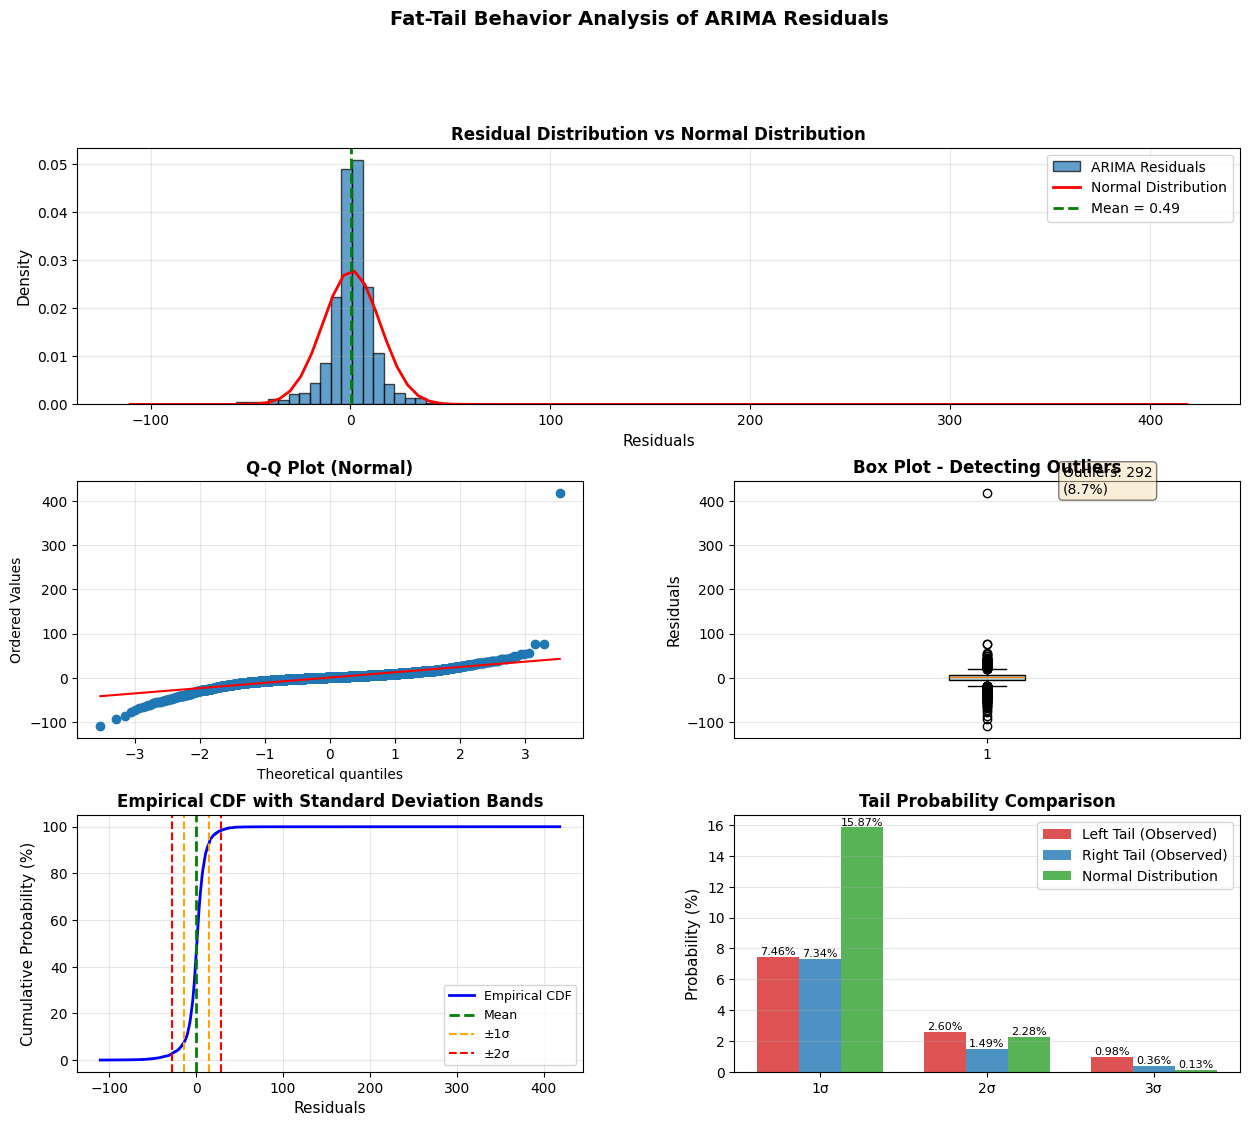


✓ Visualization saved to: plot/fat_tail_analysis.png


In [34]:
# Visualization of Fat-Tail Behavior
from scipy.stats import norm
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Histogram with Normal Distribution Overlay
ax1 = fig.add_subplot(gs[0, :])
n, bins, patches = ax1.hist(arima_residuals, bins=100, density=True, alpha=0.7, color='tab:blue', edgecolor='black', label='ARIMA Residuals')

# Overlay normal distribution
mu, sigma = arima_residuals.mean(), arima_residuals.std()
x = np.linspace(arima_residuals.min(), arima_residuals.max(), 100)
ax1.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
ax1.axvline(mu, color='green', linestyle='--', linewidth=2, label=f'Mean = {mu:.2f}')
ax1.set_xlabel('Residuals', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Residual Distribution vs Normal Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Q-Q Plot
ax2 = fig.add_subplot(gs[1, 0])
stats.probplot(arima_residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normal)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.get_lines()[0].set_color('tab:blue')
ax2.get_lines()[0].set_markeredgecolor('tab:blue')
ax2.get_lines()[1].set_color('red')

# 3. Box Plot with Outliers
ax3 = fig.add_subplot(gs[1, 1])
bp = ax3.boxplot(arima_residuals, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_edgecolor('black')
ax3.set_ylabel('Residuals', fontsize=11)
ax3.set_title('Box Plot - Detecting Outliers', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add outlier count
Q1 = arima_residuals.quantile(0.25)
Q3 = arima_residuals.quantile(0.75)
IQR = Q3 - Q1
outliers = ((arima_residuals < Q1 - 1.5*IQR) | (arima_residuals > Q3 + 1.5*IQR)).sum()
ax3.text(1.15, arima_residuals.max(), f'Outliers: {outliers}\n({outliers/len(arima_residuals)*100:.1f}%)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Tail Probability Plot
ax4 = fig.add_subplot(gs[2, 0])
sorted_residuals = np.sort(arima_residuals)
percentiles = np.arange(1, len(sorted_residuals) + 1) / len(sorted_residuals) * 100
ax4.plot(sorted_residuals, percentiles, 'b-', linewidth=2, label='Empirical CDF')
ax4.axvline(mu, color='green', linestyle='--', linewidth=2, label='Mean')
ax4.axvline(mu - sigma, color='orange', linestyle='--', linewidth=1.5, label='±1σ')
ax4.axvline(mu + sigma, color='orange', linestyle='--', linewidth=1.5)
ax4.axvline(mu - 2*sigma, color='red', linestyle='--', linewidth=1.5, label='±2σ')
ax4.axvline(mu + 2*sigma, color='red', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Residuals', fontsize=11)
ax4.set_ylabel('Cumulative Probability (%)', fontsize=11)
ax4.set_title('Empirical CDF with Standard Deviation Bands', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, loc='best')
ax4.grid(True, alpha=0.3)

# 5. Left vs Right Tail Comparison
ax5 = fig.add_subplot(gs[2, 1])
tail_categories = ['1σ', '2σ', '3σ']
left_tails = [left_tail_1std*100, left_tail_2std*100, left_tail_3std*100]
right_tails = [right_tail_1std*100, right_tail_2std*100, right_tail_3std*100]
normal_probs = [15.87, 2.28, 0.13]

x_pos = np.arange(len(tail_categories))
width = 0.25

bars1 = ax5.bar(x_pos - width, left_tails, width, label='Left Tail (Observed)', color='tab:red', alpha=0.8)
bars2 = ax5.bar(x_pos, right_tails, width, label='Right Tail (Observed)', color='tab:blue', alpha=0.8)
bars3 = ax5.bar(x_pos + width, normal_probs, width, label='Normal Distribution', color='tab:green', alpha=0.8)

ax5.set_ylabel('Probability (%)', fontsize=11)
ax5.set_title('Tail Probability Comparison', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(tail_categories)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Fat-Tail Behavior Analysis of ARIMA Residuals', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('plot/fat_tail_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: plot/fat_tail_analysis.png")

In [35]:
# Granger Causality Test: Do S&P 500 and USD/VND help explain VNI ARIMA residuals?
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd
import numpy as np

max_lag = 10

# Use ARIMA residuals already computed in the notebook
resid_series = pd.Series(arima_residuals, index=pd.to_datetime(series.index), name='vni_residuals')
resid_series = resid_series.replace([np.inf, -np.inf], np.nan).dropna()

# Load exogenous series directly from CSVs and convert to stationary log-returns
sp500_df = pd.read_csv(r'data/SP500_Full_History.csv', parse_dates=['time'])
usd_vnd_df = pd.read_csv(r'data/USDVND_Full_History.csv', parse_dates=['time'])

sp500_df = sp500_df.sort_values('time').set_index('time')
usd_vnd_df = usd_vnd_df.sort_values('time').set_index('time')

sp500_ret = np.log(sp500_df['close'].astype(float)).diff().rename('sp500_return')
usd_vnd_ret = np.log(usd_vnd_df['close'].astype(float)).diff().rename('usd_vnd_return')

# Align data on common dates
sp500_test_df = pd.concat([resid_series, sp500_ret], axis=1).dropna()
usd_vnd_test_df = pd.concat([resid_series, usd_vnd_ret], axis=1).dropna()

print('=' * 80)
print('GRANGER CAUSALITY TEST ON VNI ARIMA RESIDUALS')
print('=' * 80)
print('Note: Exogenous series are converted to log-returns to satisfy stationarity.')
print(f'Granger direction tested: exogenous series -> VNI residuals')
print(f'Max lag: {max_lag}')
print('')


def run_granger_test(test_df, explanatory_name):
    print(f'--- {explanatory_name} -> VNI residuals ---')
    print(f'Observations used: {len(test_df)}')
    print(f'Columns: {list(test_df.columns)}')
    print('Lag   SSR F-stat   p-value      Decision')
    print('-' * 50)

    results = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
    lag_rows = []

    for lag in range(1, max_lag + 1):
        f_stat, p_value, _, _ = results[lag][0]['ssr_ftest']
        decision = 'Reject H0' if p_value < 0.05 else 'Fail to reject H0'
        lag_rows.append((lag, f_stat, p_value, decision))
        print(f'{lag:<5} {f_stat:<11.4f} {p_value:<11.4f} {decision}')

    significant_lags = [row for row in lag_rows if row[2] < 0.05]
    if significant_lags:
        first_sig = significant_lags[0]
        print(f'Conclusion: {explanatory_name} Granger-causes VNI residuals at lag {first_sig[0]} and beyond some lags.')
        print(f'First significant lag p-value: {first_sig[2]:.4f}')
    else:
        print(f'Conclusion: No Granger causality detected from {explanatory_name} to VNI residuals at lags 1-{max_lag}.')
    print('')

    return lag_rows

sp500_results = run_granger_test(sp500_test_df, 'S&P 500 log return')
usd_vnd_results = run_granger_test(usd_vnd_test_df, 'USD/VND log return')

# Compact summary
print('=' * 80)
print('SUMMARY')
print('=' * 80)
for label, rows in [('S&P 500', sp500_results), ('USD/VND', usd_vnd_results)]:
    sig = [r for r in rows if r[2] < 0.05]
    if sig:
        best = min(sig, key=lambda x: x[2])
        print(f'{label}: significant Granger causality detected; strongest lag evidence at lag {best[0]} (p={best[2]:.4f}).')
    else:
        print(f'{label}: no significant Granger causality detected at any tested lag.')

GRANGER CAUSALITY TEST ON VNI ARIMA RESIDUALS
Note: Exogenous series are converted to log-returns to satisfy stationarity.
Granger direction tested: exogenous series -> VNI residuals
Max lag: 10

--- S&P 500 log return -> VNI residuals ---
Observations used: 806
Columns: ['vni_residuals', 'sp500_return']
Lag   SSR F-stat   p-value      Decision
--------------------------------------------------
1     44.4731     0.0000      Reject H0
2     22.6414     0.0000      Reject H0
3     15.1180     0.0000      Reject H0
4     11.4446     0.0000      Reject H0
5     9.3105      0.0000      Reject H0
6     7.7756      0.0000      Reject H0
7     6.6529      0.0000      Reject H0
8     6.0630      0.0000      Reject H0
9     5.5004      0.0000      Reject H0
10    5.0860      0.0000      Reject H0
Conclusion: S&P 500 log return Granger-causes VNI residuals at lag 1 and beyond some lags.
First significant lag p-value: 0.0000

--- USD/VND log return -> VNI residuals ---
Observations used: 831
Colum


Epoch comparison (selected by lowest validation MAPE):



,Epochs,Train Loss,Validation Loss,Validation RMSE,Validation MAE,Validation MAPE (%)
0,100,0.004056,0.004807,15.419278,12.619277,2.134484
1,50,0.007923,0.005808,16.949024,14.394809,2.483472
2,20,0.011975,0.007968,19.852750,16.668235,2.810973
3,30,0.006419,0.010542,22.835060,19.976700,3.389472



Best epoch count: 100 (validation MAPE = 2.134484%)

Exogenous LSTM results at selected epoch count:
Epochs: 100
RMSE  : 15.419
MAE   : 12.619
MAPE  : 2.134%


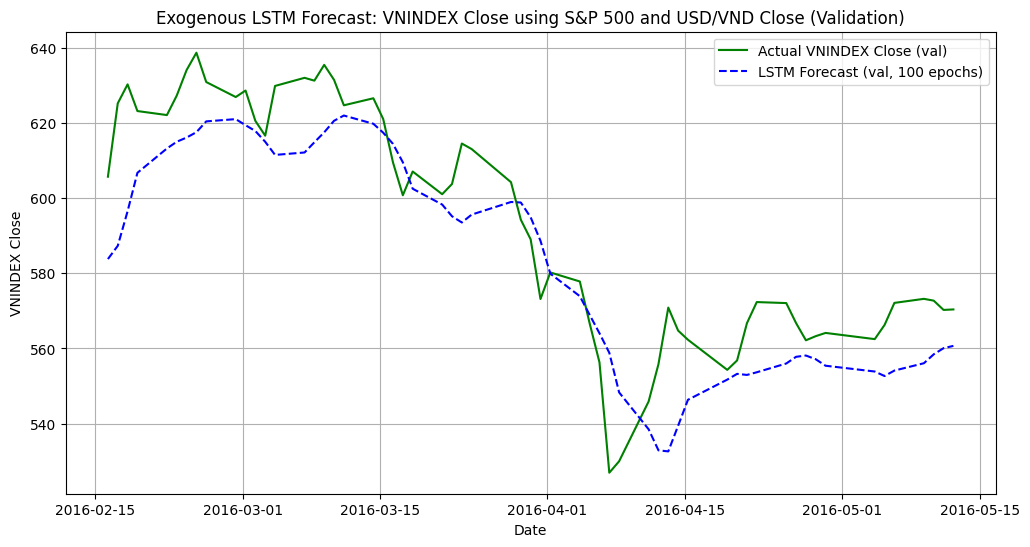

Training final model on full training set and predicting test set...


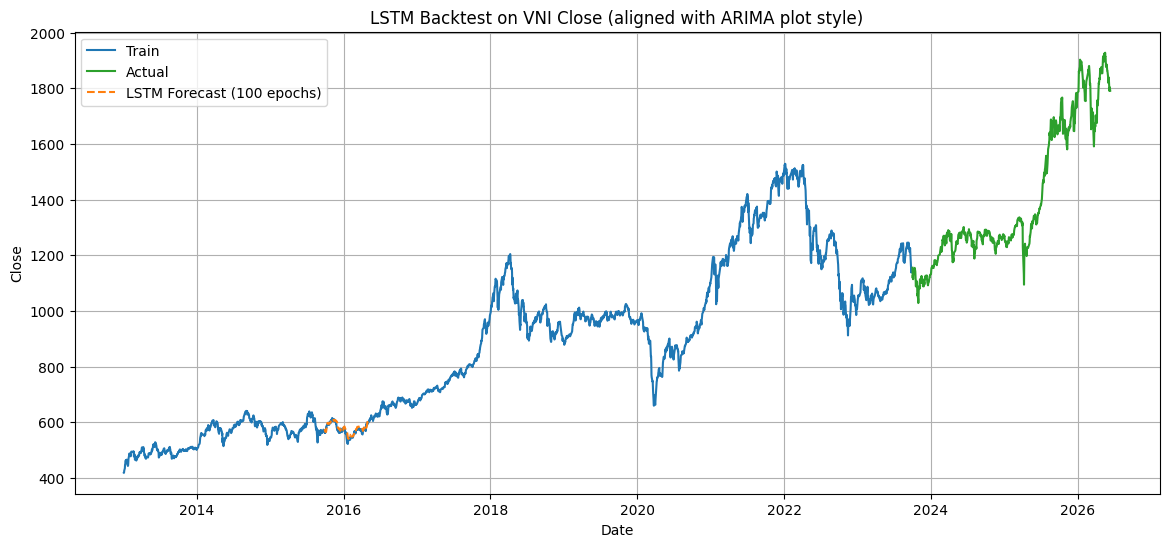

In [36]:
# Exogenous LSTM: forecast VNINDEX close using VNINDEX history + S&P 500 close + USD/VND close
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

def prepare_series(path, date_col='time', close_col='close', prefix='series'):
    frame = pd.read_csv(path)
    frame[date_col] = pd.to_datetime(frame[date_col])
    frame = frame.sort_values(date_col)[[date_col, close_col]].copy()
    frame.columns = ['time', f'{prefix}_close']
    frame[f'{prefix}_close'] = pd.to_numeric(frame[f'{prefix}_close'], errors='coerce')
    return frame

vni = df[['time', 'close', 'volume']].copy()
vni['time'] = pd.to_datetime(vni['time'])
vni = vni.sort_values('time').rename(columns={'close': 'vni_close', 'volume': 'vni_volume'})
vni['vni_close'] = pd.to_numeric(vni['vni_close'], errors='coerce')
vni['vni_volume'] = pd.to_numeric(vni['vni_volume'], errors='coerce')

sp500 = prepare_series(r'data/SP500_Full_History.csv', prefix='sp500')
fx = prepare_series(r'data/USDVND_Full_History.csv', prefix='usd_vnd')

data_lstm = vni.merge(sp500, on='time', how='inner').merge(fx, on='time', how='inner')
data_lstm = data_lstm.sort_values('time').set_index('time')
data_lstm = data_lstm[['vni_close', 'vni_volume', 'sp500_close', 'usd_vnd_close']].ffill().bfill().astype(float)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_lstm.values)

time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled, time_step)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Chronological validation split inside the training set
val_size = max(1, int(len(X_train) * 0.1))
X_fit, X_val = X_train[:-val_size], X_train[-val_size:]
y_fit, y_val = y_train[:-val_size], y_train[-val_size:]

def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.25))
    model.add(LSTM(32, return_sequences=False))
    model.add(Dropout(0.25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Try several epoch counts and choose the one with the lowest validation MAPE
epoch_candidates = [20, 30, 50, 100]
results = []
best_epoch = None
best_val_mape = np.inf
best_pred_inv = None
best_y_inv = None

for epoch_count in epoch_candidates:
    tf.keras.backend.clear_session()
    model_lstm = build_model((X_fit.shape[1], X_fit.shape[2]))
    history = model_lstm.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=epoch_count,
        batch_size=32,
        verbose=0,
        shuffle=False,
    )

    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])

    pred_scaled = model_lstm.predict(X_val, verbose=0)
    dummy_pred = np.zeros((len(pred_scaled), scaled.shape[1]))
    dummy_pred[:, 0] = pred_scaled[:, 0]
    pred_inv_val = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_y = np.zeros((len(y_val), scaled.shape[1]))
    dummy_y[:, 0] = y_val
    y_inv_val = scaler.inverse_transform(dummy_y)[:, 0]

    val_rmse = np.sqrt(mean_squared_error(y_inv_val, pred_inv_val))
    val_mae = mean_absolute_error(y_inv_val, pred_inv_val)
    val_mape = mean_absolute_percentage_error(y_inv_val, pred_inv_val) * 100

    results.append({
        'Epochs': epoch_count,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Validation RMSE': val_rmse,
        'Validation MAE': val_mae,
        'Validation MAPE (%)': val_mape,
    })

    if val_mape < best_val_mape:
        best_val_mape = val_mape
        best_epoch = epoch_count
        best_pred_inv = pred_inv_val
        best_y_inv = y_inv_val

results_df = pd.DataFrame(results).sort_values('Validation MAPE (%)').reset_index(drop=True)
print('\nEpoch comparison (selected by lowest validation MAPE):\n')
display(results_df)
print(f"\nBest epoch count: {best_epoch} (validation MAPE = {best_val_mape:.6f}%)")

# Final metrics for the selected epoch count on validation split
rmse = np.sqrt(mean_squared_error(best_y_inv, best_pred_inv))
mae = mean_absolute_error(best_y_inv, best_pred_inv)
mape = mean_absolute_percentage_error(best_y_inv, best_pred_inv) * 100

print('\nExogenous LSTM results at selected epoch count:')
print(f'Epochs: {best_epoch}')
print(f'RMSE  : {rmse:.3f}')
print(f'MAE   : {mae:.3f}')
print(f'MAPE  : {mape:.3f}%')

# Plot validation results
plt.figure(figsize=(12, 6))
idx = data_lstm.index[-len(best_y_inv):]
plt.plot(idx, best_y_inv, label='Actual VNINDEX Close (val)', color='green')
plt.plot(idx, best_pred_inv, label=f'LSTM Forecast (val, {best_epoch} epochs)', color='blue', linestyle='--')
plt.title('Exogenous LSTM Forecast: VNINDEX Close using S&P 500 and USD/VND Close (Validation)')
plt.xlabel('Date')
plt.ylabel('VNINDEX Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_lstm_validation_forecast.png', dpi=300, bbox_inches='tight')
plt.show()
# Train final model on the full training set and predict the test set
print('Training final model on full training set and predicting test set...')
tf.keras.backend.clear_session()
final_model = build_model((X_train.shape[1], X_train.shape[2]))
final_model.fit(X_train, y_train, epochs=best_epoch, batch_size=32, verbose=0)
# Predict on test set
pred_test_scaled = final_model.predict(X_test, verbose=0)
# Inverse transform predictions and actuals
dummy_pred_test = np.zeros((len(pred_test_scaled), scaled.shape[1]))
dummy_pred_test[:, 0] = pred_test_scaled[:, 0]
pred_test_inv = scaler.inverse_transform(dummy_pred_test)[:, 0]
dummy_y_test = np.zeros((len(y_test), scaled.shape[1]))
dummy_y_test[:, 0] = y_test
y_test_inv = scaler.inverse_transform(dummy_y_test)[:, 0]
# Compute test indices aligned with data_lstm (y starts at index time_step)
test_idx = data_lstm.index[time_step + split_idx: time_step + split_idx + len(y_test_inv)]
# Plot train (full), actual test (full), and LSTM forecast (aligned to LSTM test window)
plt.figure(figsize=(14, 6))
# Plot same style as ARIMA backtest: full train and full test series
plt.plot(train.index, train, label='Train', color='tab:blue')
plt.plot(test.index, test, label='Actual', color='tab:green')
# Overlay LSTM predictions where available (may be shorter than full test due to sequence window)
plt.plot(test_idx, pred_test_inv, label=f'LSTM Forecast ({best_epoch} epochs)', color='tab:orange', linestyle='--')
plt.title('LSTM Backtest on VNI Close (aligned with ARIMA plot style)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_lstm_future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()



Epoch comparison (selected by lowest mape):



,Epochs,Train Loss,Validation Loss,Test RMSE,Test MAE,Test MAPE (%),Test Correlation
0,50,0.000899,0.000901,55.042107,41.865411,2.831276,0.983543



Best epoch count: 50 (lowest mape = 2.831276)

Standalone LSTM results at selected epoch count:
Epochs: 50
RMSE  : 55.042
MAE   : 41.865
MAPE  : 2.831%
Correlation: 0.9835


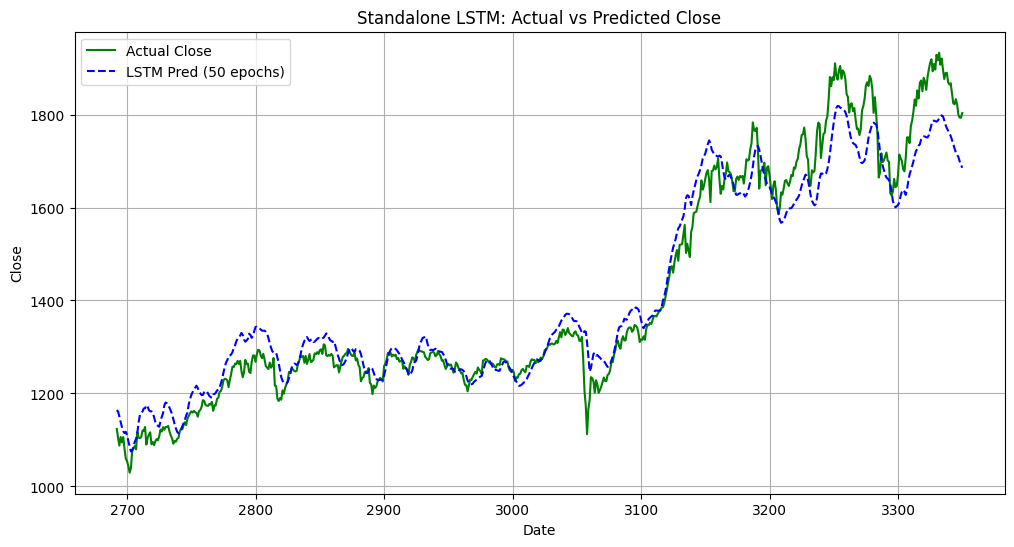

In [37]:
# Standalone LSTM: sweep epochs and evaluate predicting `Close` (multivariate inputs)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# Prepare data (use existing `df`)
data_lstm = df.copy()
date_col = 'Date'
if date_col in data_lstm.columns:
    data_lstm[date_col] = pd.to_datetime(data_lstm[date_col])
    data_lstm = data_lstm.sort_values(date_col).set_index(date_col)

features = ['open', 'high', 'low', 'close', 'volume']
data_lstm = data_lstm[features].ffill().bfill().astype(float)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data_lstm.values)

time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled, time_step)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Chronological validation split inside the training set
val_size = max(1, int(len(X_train) * 0.1))
X_fit, X_val = X_train[:-val_size], X_train[-val_size:]
y_fit, y_val = y_train[:-val_size], y_train[-val_size:]


def build_model(input_shape):
    model = Sequential()
    model.add(LSTM(48, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.25))
    model.add(LSTM(24, return_sequences=False))
    model.add(Dropout(0.25))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Try several epoch counts and choose the one with the lowest validation loss
epoch_candidates = [50]
results = []
best_epoch = None
best_mape = np.inf
best_model = None

for epoch_count in epoch_candidates:
    tf.keras.backend.clear_session()
    model_lstm = build_model((X_fit.shape[1], X_fit.shape[2]))
    history = model_lstm.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=epoch_count,
        batch_size=32,
        verbose=0,
        shuffle=False,
    )

    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])

    pred_scaled = model_lstm.predict(X_test, verbose=0)
    dummy_pred = np.zeros((len(pred_scaled), scaled.shape[1]))
    dummy_pred[:, 0] = pred_scaled[:, 0]
    pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

    dummy_y = np.zeros((len(y_test), scaled.shape[1]))
    dummy_y[:, 0] = y_test
    y_inv = scaler.inverse_transform(dummy_y)[:, 0]

    test_rmse = np.sqrt(mean_squared_error(y_inv, pred_inv))
    test_mae = mean_absolute_error(y_inv, pred_inv)
    test_mape = mean_absolute_percentage_error(y_inv, pred_inv) * 100
    test_correlation = np.corrcoef(y_inv, pred_inv)[0, 1]

    results.append({
        'Epochs': epoch_count,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test MAPE (%)': test_mape,
        'Test Correlation': test_correlation,
    })

    if test_mape < best_mape:
        best_mape = test_mape
        best_epoch = epoch_count
        best_model = model_lstm
        best_pred_inv = pred_inv
        best_y_inv = y_inv

results_df = pd.DataFrame(results).sort_values('Test MAPE (%)').reset_index(drop=True)
print('\nEpoch comparison (selected by lowest mape):\n')
display(results_df)
print(f"\nBest epoch count: {best_epoch} (lowest mape = {best_mape:.6f})")

# Final metrics for the selected epoch count
rmse = np.sqrt(mean_squared_error(best_y_inv, best_pred_inv))
mae = mean_absolute_error(best_y_inv, best_pred_inv)
mape = mean_absolute_percentage_error(best_y_inv, best_pred_inv) * 100
correlation = np.corrcoef(best_y_inv, best_pred_inv)[0, 1]

print('\nStandalone LSTM results at selected epoch count:')
print(f'Epochs: {best_epoch}')
print(f'RMSE  : {rmse:.3f}')
print(f'MAE   : {mae:.3f}')
print(f'MAPE  : {mape:.3f}%')
print(f'Correlation: {correlation:.4f}')

# Plot
plt.figure(figsize=(12, 6))
idx = data_lstm.index[-len(best_y_inv):]
plt.plot(idx, best_y_inv, label='Actual Close', color='green')
plt.plot(idx, best_pred_inv, label=f'LSTM Pred ({best_epoch} epochs)', color='blue', linestyle='--')
plt.title('Standalone LSTM: Actual vs Predicted Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_lstm_future_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

=== GIAI DOAN 1: CHUAN BI DU LIEU ===
So dong Train: 2680 | So dong Test: 671

=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===

=== GIAI DOAN 3: LSTM HOC PHAN DU ===
Dang quet nhieu phuong an epochs tren tap validation...
  Epochs: 30 (actual: 12) | Val MAPE: 1.2363%
  Epochs: 50 (actual: 24) | Val MAPE: 1.9995%
  Epochs: 80 (actual: 16) | Val MAPE: 1.9189%
  Epochs: 100 (actual: 13) | Val MAPE: 1.8831%
  Epochs: 150 (actual: 15) | Val MAPE: 1.1866%

=== Epoch Candidates Comparison (sorted by Validation MAPE) ===



,Epochs,Actual Epochs Trained,Train Loss,Validation Loss,Validation MAPE (%),Validation RMSE,Validation MAE,Validation Correlation
0,150,15,0.000576,0.000851,1.186566,14.197679,10.148084,0.101133
1,30,12,0.000607,0.000883,1.236314,14.147310,10.119418,0.145271
2,100,13,0.000620,0.000884,1.883108,14.167572,10.318633,0.147635
3,80,16,0.000549,0.000850,1.918904,14.252044,10.078557,0.135102
4,50,24,0.000512,0.000853,1.999459,14.299696,10.111031,0.116144



Best epoch count selected: 150 (Validation MAPE = 1.186566%)
Residual weight (calibrated): 1.110

=== HYBRID WALK-FORWARD TEST RESULTS (ARIMA + LSTM) ===
ARIMA order: (4, 1, 2)
Best Epoch Count: 150
RMSE : 17.565
MAE  : 11.847
MAPE : 0.829%
Correlation: 0.9975


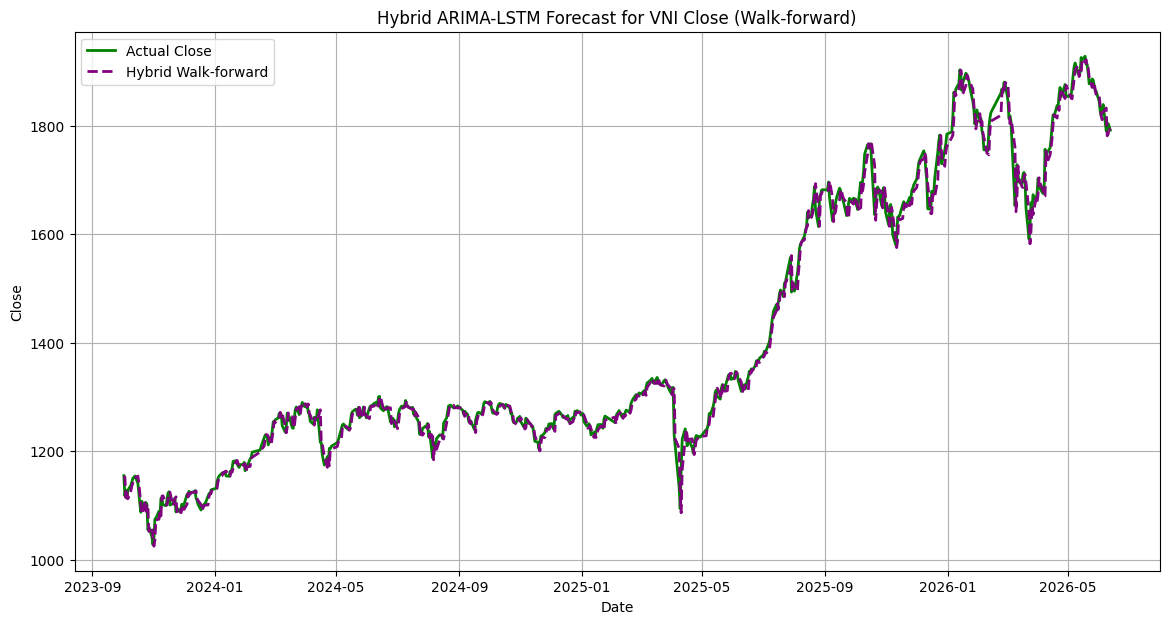

In [38]:
# %pip install tensorflow scikit-learn
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf


np.random.seed(42)
tf.random.set_seed(42)


print('=== GIAI DOAN 1: CHUAN BI DU LIEU ===')

hybrid_df = df.copy()


# Ensure all features are numeric


hybrid_df = hybrid_df.sort_values('time').dropna(subset=['close']).reset_index(drop=True)
feature_cols = ['volume', 'open', 'high', 'low']
hybrid_df[feature_cols] = hybrid_df[feature_cols].ffill().bfill()
hybrid_df = hybrid_df.set_index('time')


train_size = int(len(hybrid_df) * 0.8)
train_df = hybrid_df.iloc[:train_size].copy()
test_df = hybrid_df.iloc[train_size:].copy()


train_price = train_df['close'].astype(float)
test_price = test_df['close'].astype(float)
print(f'So dong Train: {len(train_df)} | So dong Test: {len(test_df)}')


print('\n=== GIAI DOAN 2: ARIMA WALK-FORWARD (NO FUTURE LEAK) ===')

arima_order = (4, 1, 2)
arima_model = ARIMA(train_price, order=arima_order)
arima_result = arima_model.fit()


# Train residuals
train_df['ARIMA_Pred'] = arima_result.fittedvalues
train_df['Residuals'] = train_df['close'] - train_df['ARIMA_Pred']
train_resid_df = train_df.dropna(subset=['Residuals']).copy()


# Strict one-step walk-forward: forecast t using data up to t-1, then update with actual y_t
rolling_result = arima_result
arima_test_preds = []
for y_t in test_price.values:
    forecast_one = rolling_result.forecast(steps=1)
    next_pred = float(forecast_one.iloc[0])
    arima_test_preds.append(next_pred)
    rolling_result = rolling_result.append([y_t], refit=False)
arima_test_preds = np.array(arima_test_preds)


print('\n=== GIAI DOAN 3: LSTM HOC PHAN DU ===')

features = ['Residuals', 'volume', 'open', 'high', 'low']
train_feat = train_resid_df[features].values


scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_feat)


time_step = 60

def create_dataset(dataset, step=1):
    X, y = [], []
    for i in range(len(dataset) - step):
        X.append(dataset[i:(i + step), :])
        y.append(dataset[i + step, 0])
    return np.array(X), np.array(y)


X_train_full, y_train_full = create_dataset(scaled_train, time_step)
val_size = max(1, int(len(X_train_full) * 0.1))
X_train, y_train = X_train_full[:-val_size], y_train_full[:-val_size]
X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]


# Sweep through multiple epoch candidates and select the best one
epoch_candidates = [30, 50, 80, 100, 150]
epoch_results = []
best_epoch = None
best_val_mape = np.inf
best_model_weights = None

print('Dang quet nhieu phuong an epochs tren tap validation...')

for epoch_count in epoch_candidates:
    tf.keras.backend.clear_session()
    
    model = Sequential()
    model.add(LSTM(units=48, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.25))
    model.add(LSTM(units=24, return_sequences=False))
    model.add(Dropout(0.25))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]
    
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epoch_count,
        batch_size=32,
        verbose=0,
        shuffle=False,
        callbacks=callbacks
    )
    
    actual_epochs = len(history.history['loss'])
    train_loss = float(history.history['loss'][-1])
    val_loss = float(history.history['val_loss'][-1])
    
    # Compute validation MAPE
    val_scaled_pred = model.predict(X_val, verbose=0)
    dummy_val = np.zeros((len(val_scaled_pred), len(features)))
    dummy_val[:, 0] = val_scaled_pred[:, 0]
    val_res_pred = scaler.inverse_transform(dummy_val)[:, 0]
    
    dummy_y_val = np.zeros((len(y_val), len(features)))
    dummy_y_val[:, 0] = y_val
    val_res_true = scaler.inverse_transform(dummy_y_val)[:, 0]
    
    val_mape = mean_absolute_percentage_error(val_res_true, val_res_pred)
    val_rmse = np.sqrt(mean_squared_error(val_res_true, val_res_pred))
    val_mae = mean_absolute_error(val_res_true, val_res_pred)
    val_correlation = np.corrcoef(val_res_true, val_res_pred)[0, 1]
    
    epoch_results.append({
        'Epochs': epoch_count,
        'Actual Epochs Trained': actual_epochs,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Validation MAPE (%)': val_mape,
        'Validation RMSE': val_rmse,
        'Validation MAE': val_mae,
        'Validation Correlation': val_correlation,
    })
    
    print(f"  Epochs: {epoch_count} (actual: {actual_epochs}) | Val MAPE: {val_mape:.4f}%")
    
    if val_mape < best_val_mape:
        best_val_mape = val_mape
        best_epoch = epoch_count
        best_model_weights = model.get_weights()

# Display epoch comparison
epoch_results_df = pd.DataFrame(epoch_results).sort_values('Validation MAPE (%)').reset_index(drop=True)
print('\n=== Epoch Candidates Comparison (sorted by Validation MAPE) ===\n')
display(epoch_results_df)
print(f"\nBest epoch count selected: {best_epoch} (Validation MAPE = {best_val_mape:.6f}%)")


# Rebuild model with best epoch and load weights
tf.keras.backend.clear_session()
model = Sequential()
model.add(LSTM(units=48, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.25))
model.add(LSTM(units=24, return_sequences=False))
model.add(Dropout(0.25))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.set_weights(best_model_weights)

# Calibrate residual correction strength on validation (train-only)
val_scaled_pred = model.predict(X_val, verbose=0)
dummy_val = np.zeros((len(val_scaled_pred), len(features)))
dummy_val[:, 0] = val_scaled_pred[:, 0]
val_res_pred = scaler.inverse_transform(dummy_val)[:, 0]


dummy_y_val = np.zeros((len(y_val), len(features)))
dummy_y_val[:, 0] = y_val
val_res_true = scaler.inverse_transform(dummy_y_val)[:, 0]


den = float(np.dot(val_res_pred, val_res_pred))
if den > 0:
    residual_weight = float(np.dot(val_res_true, val_res_pred) / den)
else:
    residual_weight = 1.0
residual_weight = float(np.clip(residual_weight, 0.2, 1.2))
print(f'Residual weight (calibrated): {residual_weight:.3f}')


# Residual forecast each day, then update window with realized residual (available after day close)
window_scaled = scaled_train[-time_step:, :].copy()
test_exog = test_df[['volume', 'open', 'high', 'low']].values
actual_test_price = test_price.values


final_hybrid_pred = []


for i in range(len(test_df)):
    x_input = window_scaled.reshape(1, time_step, len(features))
    pred_res_scaled = model.predict(x_input, verbose=0)[0, 0]

    dummy = np.zeros((1, len(features)))
    dummy[0, 0] = pred_res_scaled
    pred_residual = scaler.inverse_transform(dummy)[0, 0]

    yhat = arima_test_preds[i] + residual_weight * pred_residual
    final_hybrid_pred.append(yhat)

    # Update window with realized residual at current step (strictly past info for next step)
    realized_residual = actual_test_price[i] - arima_test_preds[i]
    next_row_raw = np.array([
        realized_residual,
        test_exog[i, 0],
        test_exog[i, 1],
        test_exog[i, 2],
        test_exog[i, 3]
    ], dtype=float).reshape(1, -1)
    next_row_scaled = scaler.transform(next_row_raw)
    window_scaled = np.vstack([window_scaled[1:], next_row_scaled])


final_hybrid_pred = np.array(final_hybrid_pred)
test_dates = test_df.index


valid_mask = np.isfinite(final_hybrid_pred) & np.isfinite(actual_test_price)
final_hybrid_pred = final_hybrid_pred[valid_mask]
actual_test_price = actual_test_price[valid_mask]
test_dates = test_dates[valid_mask]


rmse = np.sqrt(mean_squared_error(actual_test_price, final_hybrid_pred))
mae = mean_absolute_error(actual_test_price, final_hybrid_pred)
mape = mean_absolute_percentage_error(actual_test_price, final_hybrid_pred) * 100
correlation = np.corrcoef(actual_test_price, final_hybrid_pred)[0, 1]


print('\n=== HYBRID WALK-FORWARD TEST RESULTS (ARIMA + LSTM) ===')
print(f'ARIMA order: {arima_order}')
print(f'Best Epoch Count: {best_epoch}')
print(f'RMSE : {rmse:.3f}')
print(f'MAE  : {mae:.3f}')
print(f'MAPE : {mape:.3f}%')
print(f'Correlation: {correlation:.4f}')


plt.figure(figsize=(14, 7))
plt.plot(test_dates, actual_test_price, label='Actual Close', color='green', linewidth=2)
plt.plot(test_dates, final_hybrid_pred, label='Hybrid Walk-forward', color='purple', linestyle='--', linewidth=2)
plt.title('Hybrid ARIMA-LSTM Forecast for VNI Close (Walk-forward)')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend()
plt.grid(True)
plt.savefig('plot/vni_hybrid_walk_forward.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
# Diebold-Mariano Test: ARIMA vs Hybrid, Standalone LSTM vs Hybrid
from scipy.stats import norm
import numpy as np
import pandas as pd


def diebold_mariano_test(actual, pred_1, pred_2, horizon=1, loss='squared'):
    actual = np.asarray(actual, dtype=float)
    pred_1 = np.asarray(pred_1, dtype=float)
    pred_2 = np.asarray(pred_2, dtype=float)

    n = min(len(actual), len(pred_1), len(pred_2))
    actual = actual[:n]
    pred_1 = pred_1[:n]
    pred_2 = pred_2[:n]

    e1 = actual - pred_1
    e2 = actual - pred_2

    if loss == 'squared':
        d = e1 ** 2 - e2 ** 2
    elif loss == 'absolute':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    d = d - np.mean(d)
    n = len(d)
    if n < 2:
        raise ValueError('Not enough observations for DM test')

    gamma0 = np.sum(d ** 2) / n
    var_d = gamma0

    if horizon > 1:
        for lag in range(1, horizon):
            autocov = np.sum(d[lag:] * d[:-lag]) / n
            var_d += 2 * (1 - lag / horizon) * autocov

    dm_stat = np.mean(e1 ** 2 - e2 ** 2) / np.sqrt(var_d / n)
    harvey_adj = np.sqrt((n + 1 - 2 * horizon + (horizon * (horizon - 1) / n)) / n)
    dm_stat_adj = dm_stat * harvey_adj
    p_value = 2 * (1 - norm.cdf(abs(dm_stat_adj)))

    return {
        'dm_stat': dm_stat_adj,
        'p_value': p_value,
        'n_obs': n,
        'mean_diff': np.mean(e1 ** 2 - e2 ** 2),
        'loss': loss,
    }


print('=' * 80)
print('DIEBOLD-MARIANO TEST')
print('=' * 80)
print('Loss function: squared error')
print('H0: both models have equal predictive accuracy')
print('H1: predictive accuracy differs')
print('')

# Pair 1: ARIMA vs Hybrid
if 'actual_test_price' in globals() and 'arima_test_preds' in globals() and 'final_hybrid_pred' in globals():
    dm_arima_hybrid = diebold_mariano_test(actual_test_price, arima_test_preds, final_hybrid_pred, horizon=1, loss='squared')
    better_model = 'Hybrid' if dm_arima_hybrid['mean_diff'] > 0 else 'ARIMA'
    print('ARIMA vs Hybrid')
    print(f"  Observations: {dm_arima_hybrid['n_obs']}")
    print(f"  DM statistic: {dm_arima_hybrid['dm_stat']:.4f}")
    print(f"  p-value:      {dm_arima_hybrid['p_value']:.6f}")
    print(f"  Mean loss diff (ARIMA - Hybrid): {dm_arima_hybrid['mean_diff']:.6f}")
    if dm_arima_hybrid['p_value'] < 0.05:
        print(f"  Conclusion: Reject H0. {better_model} has significantly better predictive accuracy.")
    else:
        print('  Conclusion: Fail to reject H0. No significant accuracy difference.')
else:
    print('ARIMA vs Hybrid')
    print('  Required variables not found: actual_test_price, arima_test_preds, final_hybrid_pred')

print('')

# Pair 2: Standalone LSTM vs Hybrid
# Use the standalone LSTM evaluation arrays if they are present in the kernel.
standalone_actual = None
standalone_pred = None

candidate_actual_names = ['test', 'actual_test_price', 'test_inv', 'y_test', 'actual']
candidate_pred_names = ['pred', 'pred_inv', 'lstm_pred', 'test_pred', 'pred_test_inv']

for name in candidate_actual_names:
    if name in globals():
        standalone_actual = globals()[name]
        break

for name in candidate_pred_names:
    if name in globals():
        standalone_pred = globals()[name]
        break

if standalone_actual is not None and standalone_pred is not None and 'final_hybrid_pred' in globals():
    dm_lstm_hybrid = diebold_mariano_test(standalone_actual, standalone_pred, final_hybrid_pred, horizon=1, loss='squared')
    better_model = 'Hybrid' if dm_lstm_hybrid['mean_diff'] > 0 else 'Standalone LSTM'
    print('Standalone LSTM vs Hybrid')
    print(f"  Observations: {dm_lstm_hybrid['n_obs']}")
    print(f"  DM statistic: {dm_lstm_hybrid['dm_stat']:.4f}")
    print(f"  p-value:      {dm_lstm_hybrid['p_value']:.6f}")
    print(f"  Mean loss diff (Standalone LSTM - Hybrid): {dm_lstm_hybrid['mean_diff']:.6f}")
    if dm_lstm_hybrid['p_value'] < 0.05:
        print(f"  Conclusion: Reject H0. {better_model} has significantly better predictive accuracy.")
    else:
        print('  Conclusion: Fail to reject H0. No significant accuracy difference.')
else:
    print('Standalone LSTM vs Hybrid')
    print('  Required variables not found for standalone LSTM comparison.')
    print('  Expected an actual series and a prediction series among:')
    print(f"  actual candidates = {candidate_actual_names}")
    print(f"  prediction candidates = {candidate_pred_names}")

DIEBOLD-MARIANO TEST
Loss function: squared error
H0: both models have equal predictive accuracy
H1: predictive accuracy differs

ARIMA vs Hybrid
  Observations: 671
  DM statistic: -2.2133
  p-value:      0.026877
  Mean loss diff (ARIMA - Hybrid): -10.715737
  Conclusion: Reject H0. ARIMA has significantly better predictive accuracy.

Standalone LSTM vs Hybrid
  Observations: 671
  DM statistic: 18.7028
  p-value:      0.000000
  Mean loss diff (Standalone LSTM - Hybrid): 123746.038376
  Conclusion: Reject H0. Hybrid has significantly better predictive accuracy.
